# 02: Estimates — D&K replication

Loads `outputs/py/dk_clean_v2.parquet`. Sections 1–6: incidence, D&K
validation (rows 1–4), pooled dk/kq penalties, by-period dk/kq penalties,
union mediation (kq), and summary statistics (kq). Stops after section 6.

Sources: `refs/dk_spec.md`, `refs/kq_spec.md`, `refs/cleaning.md` govern the
model/sample/variable definitions; `CLAUDE.md` governs output conventions
(long-format estimates, `outputs/py/`, `outputs/figures/`).

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pyfixest as pf

os.makedirs("../outputs/py", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

dk_clean = pd.read_parquet("../outputs/py/dk_clean_v2.parquet")
dk_published_penalty = pd.read_csv("../data/comparisons/dk_published_penalty.csv")
print(dk_clean.shape)

(166391, 49)


## 1. Incidence of outsourcing

Source: `refs/dk_spec.md`, "## Incidence of outsourcing (D&K Table 1)".
Incidence has no covariates, so it is identical for the dk and kq specs —
computed once here.

Benchmark: `data/comparisons/dk_published_incidence.csv` (role: benchmark,
hand-entered from D&K Table 1). That file has no standard errors and no
change-row value, so this notebook reports its own SEs/change row without
inventing a D&K figure to compare them to (per `refs/dk_spec.md`: "these
files are the only source of D&K values; never invent others").

In [ ]:
def weighted_incidence(g):
    # share = sum(EARNWT * outsourced) / sum(EARNWT); se = binomial SE with
    # Kish effective N (refs/dk_spec.md, replication choice)
    w = g["EARNWT"].to_numpy(dtype=float)
    o = g["outsourced"].to_numpy(dtype=float)
    share = np.sum(w * o) / np.sum(w)
    n_eff = (np.sum(w) ** 2) / np.sum(w ** 2)
    se = np.sqrt(share * (1 - share) / n_eff)
    return pd.Series({"share": share, "se": se, "n": int((g["EARNWT"] > 0).sum()), "n_eff": n_eff})

incidence_annual = (
    dk_clean.groupby(["occupation", "YEAR"])
    .apply(weighted_incidence, include_groups=False)
    .reset_index()
)
incidence_annual["ci_lo"] = incidence_annual["share"] - 1.96 * incidence_annual["se"]
incidence_annual["ci_hi"] = incidence_annual["share"] + 1.96 * incidence_annual["se"]
print(incidence_annual.shape)
incidence_annual.head()

(84, 8)


,occupation,YEAR,share,se,n,n_eff,ci_lo,ci_hi
0,guard,1983,0.360568,0.016018,1094.0,898.583777,0.329173,0.391964
1,guard,1984,0.363815,0.016222,1076.0,879.508025,0.332019,0.395610
2,guard,1985,0.383748,0.016141,1120.0,907.649535,0.352111,0.415385
3,guard,1986,0.366503,0.015570,1155.0,957.787104,0.335987,0.397019
4,guard,1987,0.396440,0.015842,1184.0,953.394947,0.365389,0.427490


In [ ]:
# D&K Table 1: 3-year bins, 1983-2000, plus a change row (share(1998-2000) - share(1983-85))
dk_bins = [(1983, 1985), (1986, 1988), (1989, 1991), (1992, 1994), (1995, 1997), (1998, 2000)]

def bin_incidence(occ, y0, y1):
    g = dk_clean[(dk_clean["occupation"] == occ) & dk_clean["YEAR"].between(y0, y1)]
    return {"occ": occ, "year_start": y0, "year_end": y1, **weighted_incidence(g)}

incidence_bins = pd.DataFrame(
    [bin_incidence(occ, y0, y1) for occ in ["janitor", "guard"] for (y0, y1) in dk_bins]
)
incidence_bins["label"] = (
    incidence_bins["year_start"].astype(int).astype(str) + "-" + incidence_bins["year_end"].astype(int).astype(str)
)

change_rows = []
for occ in ["janitor", "guard"]:
    s1 = incidence_bins[(incidence_bins["occ"] == occ) & (incidence_bins["year_start"] == 1983)].iloc[0]
    s2 = incidence_bins[(incidence_bins["occ"] == occ) & (incidence_bins["year_start"] == 1998)].iloc[0]
    change_rows.append({
        "occ": occ, "year_start": np.nan, "year_end": np.nan,
        "share": s2["share"] - s1["share"],
        "se": np.sqrt(s1["se"] ** 2 + s2["se"] ** 2),
        "n": np.nan, "n_eff": np.nan, "label": "change (1998-2000 minus 1983-85)",
    })
incidence_bins = pd.concat([incidence_bins, pd.DataFrame(change_rows)], ignore_index=True)
print(incidence_bins.round(4))

        occ  year_start  year_end   share      se        n      n_eff  \
0   janitor      1983.0    1985.0  0.1316  0.0036  11554.0  9061.8145   
1   janitor      1986.0    1988.0  0.1505  0.0039  10937.0  8374.2747   
2   janitor      1989.0    1991.0  0.1643  0.0041  10732.0  8091.2706   
3   janitor      1992.0    1994.0  0.1832  0.0045   9716.0  7239.0679   
4   janitor      1995.0    1997.0  0.1899  0.0047   8798.0  6839.0536   
5   janitor      1998.0    2000.0  0.1772  0.0046   8590.0  6783.8443   
6     guard      1983.0    1985.0  0.3696  0.0093   3290.0  2685.4273   
7     guard      1986.0    1988.0  0.3820  0.0094   3433.0  2682.3576   
8     guard      1989.0    1991.0  0.3952  0.0096   3293.0  2567.6270   
9     guard      1992.0    1994.0  0.4326  0.0099   3312.0  2514.0624   
10    guard      1995.0    1997.0  0.4714  0.0105   2844.0  2277.5899   
11    guard      1998.0    2000.0  0.4715  0.0103   2866.0  2343.4501   
12  janitor         NaN       NaN  0.0456  0.0058  

In [ ]:
# Comparison table: my 3-year bins vs. D&K published Table 1
dk_published_incidence = pd.read_csv("../data/comparisons/dk_published_incidence.csv")
occ_map = {"janitor": "Janitors", "guard": "Guards"}

mine = incidence_bins[incidence_bins["label"] != "change (1998-2000 minus 1983-85)"].copy()
mine["occ_label"] = mine["occ"].map(occ_map)
mine["year_start"] = mine["year_start"].astype(int)
mine["year_end"] = mine["year_end"].astype(int)

bench = dk_published_incidence.rename(columns={"occ": "occ_label", "share": "dk_share"})
incidence_comparison = mine.merge(bench, on=["occ_label", "year_start", "year_end"], how="left")
incidence_comparison["diff"] = incidence_comparison["share"] - incidence_comparison["dk_share"]
incidence_comparison = incidence_comparison[
    ["occ", "year_start", "year_end", "share", "se", "dk_share", "diff"]
].rename(columns={"share": "my_share", "se": "my_se"})
print(incidence_comparison.round(4).to_string(index=False))

    occ  year_start  year_end  my_share  my_se  dk_share    diff
janitor        1983      1985    0.1316 0.0036     0.164 -0.0324
janitor        1986      1988    0.1505 0.0039     0.182 -0.0315
janitor        1989      1991    0.1643 0.0041     0.210 -0.0457
janitor        1992      1994    0.1832 0.0045     0.227 -0.0438
janitor        1995      1997    0.1899 0.0047     0.231 -0.0411
janitor        1998      2000    0.1772 0.0046     0.216 -0.0388
  guard        1983      1985    0.3696 0.0093     0.401 -0.0314
  guard        1986      1988    0.3820 0.0094     0.411 -0.0290
  guard        1989      1991    0.3952 0.0096     0.424 -0.0288
  guard        1992      1994    0.4326 0.0099     0.462 -0.0294
  guard        1995      1997    0.4714 0.0105     0.497 -0.0256
  guard        1998      2000    0.4715 0.0103     0.497 -0.0255


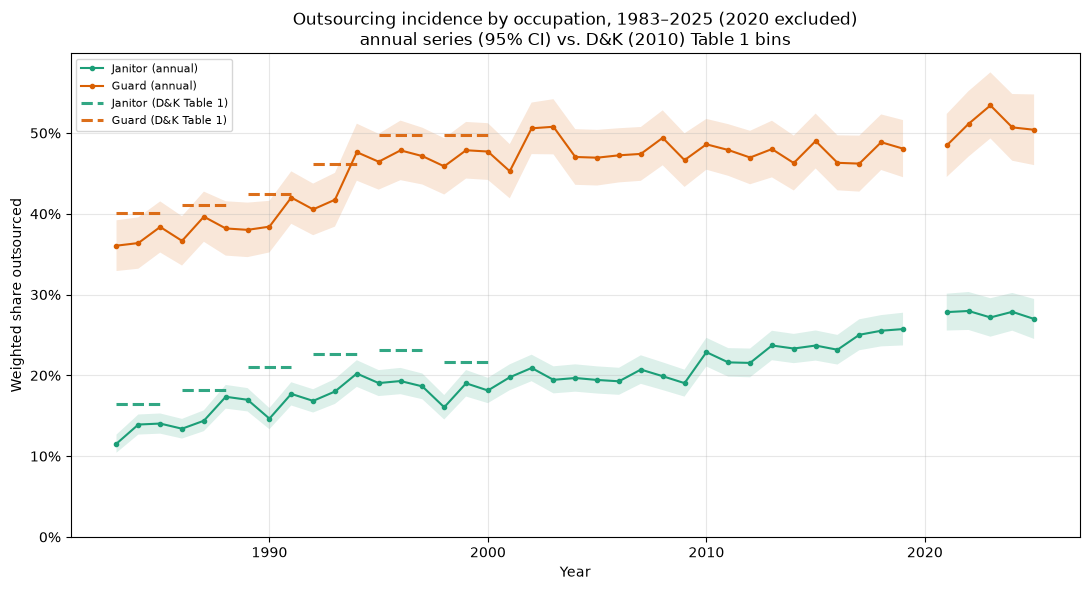

In [ ]:
# Annual series with 95% CIs, line broken at 2020, D&K Table 1 shares as horizontal
# segments over their periods
years_full = pd.Index(range(1983, 2026), name="YEAR")
wide_share = incidence_annual.pivot(index="YEAR", columns="occupation", values="share").reindex(years_full)
wide_se = incidence_annual.pivot(index="YEAR", columns="occupation", values="se").reindex(years_full)

dk_published_incidence["occ_key"] = dk_published_incidence["occ"].map({"Janitors": "janitor", "Guards": "guard"})

fig, ax = plt.subplots(figsize=(11, 6))
colors = {"janitor": "#1b9e77", "guard": "#d95f02"}
for occ in ["janitor", "guard"]:
    share, se = wide_share[occ], wide_se[occ]
    ax.plot(years_full, share, marker="o", markersize=3, linewidth=1.5, color=colors[occ], label=f"{occ.capitalize()} (annual)")
    ax.fill_between(years_full, share - 1.96 * se, share + 1.96 * se, color=colors[occ], alpha=0.15, linewidth=0)

first_seg = {"janitor": True, "guard": True}
for _, row in dk_published_incidence.iterrows():
    lab = f"{row['occ_key'].capitalize()} (D&K Table 1)" if first_seg[row["occ_key"]] else None
    first_seg[row["occ_key"]] = False
    ax.plot([row["year_start"], row["year_end"]], [row["share"], row["share"]],
            color=colors[row["occ_key"]], linestyle="--", linewidth=2.2, alpha=0.9, label=lab)

ax.set_xlabel("Year")
ax.set_ylabel("Weighted share outsourced")
ax.set_title("Outsourcing incidence by occupation, 1983\u20132025 (2020 excluded)\nannual series (95% CI) vs. D&K (2010) Table 1 bins")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_ylim(0, None)
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../outputs/figures/incidence_annual.png", dpi=150)
plt.show()

In [ ]:
incidence_annual.to_csv("../outputs/py/incidence_annual.csv", index=False)
incidence_bins.to_csv("../outputs/py/incidence_table1_bins.csv", index=False)
incidence_comparison.to_csv("../outputs/py/incidence_table1_vs_dk.csv", index=False)
print("saved incidence outputs")

saved incidence outputs


## Shared setup: formulas, terms, and a long-format recorder

Used by sections 2–6. `fit_and_record` fits a model, appends every
coefficient to `master` (the accumulator saved as `outputs/py/estimates.csv`
at the end, in `CLAUDE.md`'s long format: `lang, spec, model, occ, sample,
term, estimate, se, t, p, n_obs`), and caches the fit + its sample in
`fit_cache` so later sections (mediation) can reuse it instead of refitting.

In [ ]:
dk_terms = ["log_wage", "outsourced", "union", "parttime", "educ_cat", "female", "black",
            "hispanic", "age", "age2", "msa", "central_city", "cc_unknown", "geo_unidentified"]
kq_terms = dk_terms + ["gov_employee"]
nofemale_terms = [t for t in dk_terms if t != "female"]
kq_nounion_terms = [t for t in kq_terms if t != "union"]

dk_formula = (
    "log_wage ~ outsourced + union + parttime + educ_cat + female + black + hispanic "
    "+ age + age2 + msa + central_city + cc_unknown + geo_unidentified | STATEFIP^YEAR"
)
nofemale_formula = dk_formula.replace("female + ", "")
interact_formula = dk_formula.replace(" | STATEFIP^YEAR", " + union_x_outsourced + parttime_x_outsourced | STATEFIP^YEAR")
kq_formula = dk_formula.replace(" | STATEFIP^YEAR", " + gov_employee | STATEFIP^YEAR")
kq_nounion_formula = kq_formula.replace("outsourced + union + parttime", "outsourced + parttime")

master = []     # long-format accumulator across all sections
fit_cache = {}  # (occ, spec, model, sample) -> (fit, sample_df)

def record(fit, lang, spec, model, occ, sample):
    t = fit.tidy().reset_index()
    for _, r in t.iterrows():
        master.append(dict(lang=lang, spec=spec, model=model, occ=occ, sample=sample,
                            term=r["Coefficient"], estimate=r["Estimate"], se=r["Std. Error"],
                            t=r["t value"], p=r["Pr(>|t|)"], n_obs=fit._N))

def fit_and_record(formula, data, terms, lang, spec, model, occ, sample):
    s = data.dropna(subset=terms).copy()
    fit = pf.feols(formula, data=s, weights="EARNWT", vcov={"CRV1": "ym"})
    record(fit, lang, spec, model, occ, sample)
    fit_cache[(occ, spec, model, sample)] = (fit, s)
    return fit, s

## 2. D&K validation (rows 1–4), 1983–2000

Source: `refs/dk_spec.md`, "## Wage regression", "## Additional D&K rows
replicated (1983-2000 only)", and "## D&K published benchmarks".

**Rows:** 1 = baseline formula, full sample. 2 = formula minus `female`,
women only. 3 = formula minus `female`, men only. 4 = formula plus
`union_x_outsourced` and `parttime_x_outsourced`.

Benchmark: `data/comparisons/dk_published_penalty.csv` (D&K Tables 3a/3b,
rows 1–9; only rows 1–4 used here).

**Sample labels** follow `CLAUDE.md`'s Outputs section: `"1983-2000"` for
rows 1/4, `"1983-2000_female"` / `"1983-2000_male"` for rows 2/3.

**N check:** `refs/dk_spec.md` says to check N against the benchmark before
comparing coefficients. Three candidate explanations are reported below for
the gap found — local-government exclusion (the deferred issue in
`CLAUDE.md`), allocated/imputed earnings (untestable here — no allocation
flag in the extract), and geography complete cases (a documented choice in
`refs/dk_spec.md`) — without ranking them; the cause is not established.

**Sex-label swap (janitors only):** `refs/dk_spec.md` states the paper's
janitor row 2/3 labels are treated as transposed (reported N's imply 69%
female; CPS janitors are ~31% female, 1983–2000). The comparison below pairs
my female subsample with the paper's "Baseline (Male)" row and my male
subsample with "Baseline (Female)", on every term and N. This reports that
pairing; it does not argue for it beyond what's in the spec.

In [ ]:
dk_samples = {}
for occ in ["janitor", "guard"]:
    s = dk_clean[(dk_clean["occupation"] == occ) & dk_clean["replication_sample"]].dropna(subset=dk_terms).copy()
    dk_samples[occ] = s
    print(occ, "row1/2/3/4 regression sample N:", len(s))

bench_n = dk_published_penalty[dk_published_penalty["row"] == 1][["occ", "n"]].drop_duplicates()
print()
for occ in ["janitor", "guard"]:
    my_n = len(dk_samples[occ])
    dk_n = bench_n.loc[bench_n["occ"] == occ.capitalize() + "s", "n"].iloc[0]
    print(f"{occ}: my N = {my_n}, D&K row-1 N = {dk_n}, ratio = {my_n / dk_n:.2f}x")

janitor row1/2/3/4 regression sample N: 57297
guard row1/2/3/4 regression sample N: 18253

janitor: my N = 57297, D&K row-1 N = 33222, ratio = 1.72x
guard: my N = 18253, D&K row-1 N = 11116, ratio = 1.64x


In [ ]:
# N-gap candidates -- reported neutrally; do not adjust cleaning/spec to close the gap,
# and do not conclude which candidate (if any) is the cause.
for occ in ["janitor", "guard"]:
    s = dk_samples[occ]
    geoclean_n = len(s[(s["cc_unknown"] == 0) & (s["geo_unidentified"] == 0)])
    nonlocalgov_n = len(s[s["CLASSWKR"] != 28])
    print(f"{occ}: full N={len(s)} "
          f"| excl. unidentified/unknown geography: {geoclean_n} "
          f"| excl. local government (CLASSWKR==28): {nonlocalgov_n}")

janitor: full N=57297 | excl. unidentified/unknown geography: 47544 | excl. local government (CLASSWKR==28): 46062
guard: full N=18253 | excl. unidentified/unknown geography: 15384 | excl. local government (CLASSWKR==28): 17168


In [ ]:
# Context for the sex-label swap (not a re-derivation -- refs/dk_spec.md already settles it)
for occ in ["janitor", "guard"]:
    fshare = np.average(dk_samples[occ]["female"], weights=dk_samples[occ]["EARNWT"])
    print(f"{occ}: weighted female share (1983-2000 regression sample) = {fshare:.4f}")

janitor: weighted female share (1983-2000 regression sample) = 0.3095
guard: weighted female share (1983-2000 regression sample) = 0.1606


In [ ]:
for occ in ["janitor", "guard"]:
    s = dk_samples[occ]
    fit_and_record(dk_formula, s, dk_terms, "python", "dk", "base", occ, "1983-2000")
    fit_and_record(nofemale_formula, s[s["female"] == 1], nofemale_terms, "python", "dk", "base", occ, "1983-2000_female")
    fit_and_record(nofemale_formula, s[s["female"] == 0], nofemale_terms, "python", "dk", "base", occ, "1983-2000_male")
    fit_and_record(interact_formula, s, dk_terms, "python", "dk", "interactions", occ, "1983-2000")

estimates_s2 = pd.DataFrame(master)  # snapshot; sections 3-6 keep appending to `master`
print(estimates_s2.shape)

/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 2 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 206 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 5 singleton fixed effect(s) dropped from the model.
  warnings.warn(


(136, 11)


/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 2 singleton fixed effect(s) dropped from the model.
  warnings.warn(


In [ ]:
# Confirm college is the omitted educ_cat level, and cc_unknown/geo_unidentified are
# in the model, by inspecting the full row-1 coefficient table for each occupation.
for occ in ["janitor", "guard"]:
    names = fit_cache[(occ, "dk", "base", "1983-2000")][0]._coefnames
    print(occ, "college omitted:", "educ_cat[T.college]" not in names,
          "| cc_unknown present:", "cc_unknown" in names,
          "| geo_unidentified present:", "geo_unidentified" in names)

janitor college omitted: True | cc_unknown present: True | geo_unidentified present: True
guard college omitted: True | cc_unknown present: True | geo_unidentified present: True


In [ ]:
# Benchmark comparison: map each (sample, model) to the matching D&K row number, applying
# the sex-label transposition for janitors only (per refs/dk_spec.md).
def benchmark_row(occ, sample, model):
    if sample == "1983-2000" and model == "base":
        return 1
    if sample == "1983-2000" and model == "interactions":
        return 4
    if sample == "1983-2000_female":
        return 3 if occ == "janitor" else 2
    if sample == "1983-2000_male":
        return 2 if occ == "janitor" else 3
    raise ValueError((sample, model))

estimates_s2 = estimates_s2.copy()
estimates_s2["benchmark_row"] = estimates_s2.apply(lambda r: benchmark_row(r["occ"], r["sample"], r["model"]), axis=1)
estimates_s2["occ_label"] = estimates_s2["occ"].map({"janitor": "Janitors", "guard": "Guards"})

bench = dk_published_penalty.rename(columns={"estimate": "dk_estimate", "se": "dk_se", "n": "dk_n", "label": "dk_label"})
rows1_4_vs_dk = estimates_s2.merge(
    bench, left_on=["occ_label", "benchmark_row", "term"], right_on=["occ", "row", "term"],
    how="left", suffixes=("", "_bench"),
)
rows1_4_vs_dk["diff"] = rows1_4_vs_dk["estimate"] - rows1_4_vs_dk["dk_estimate"]
display_cols = ["occ", "model", "sample", "benchmark_row", "dk_label", "term",
                 "estimate", "se", "dk_estimate", "dk_se", "diff", "n_obs", "dk_n"]
print(rows1_4_vs_dk[display_cols].round(4).to_string(index=False))

    occ        model           sample  benchmark_row                   dk_label                     term  estimate     se  dk_estimate  dk_se    diff  n_obs    dk_n
janitor         base        1983-2000              1                   Baseline               outsourced   -0.0472 0.0043       -0.045  0.005 -0.0022  57297 33222.0
janitor         base        1983-2000              1                   Baseline                    union    0.2466 0.0047        0.298  0.007 -0.0514  57297 33222.0
janitor         base        1983-2000              1                   Baseline                 parttime   -0.1574 0.0041       -0.173  0.005  0.0156  57297 33222.0
janitor         base        1983-2000              1                        NaN    educ_cat[T.no_school]   -0.1838 0.0226          NaN    NaN     NaN  57297     NaN
janitor         base        1983-2000              1                        NaN      educ_cat[T.primary]   -0.1187 0.0104          NaN    NaN     NaN  57297     NaN
janitor   

In [ ]:
# The transposed-label pairing in isolation (janitor only), all terms and N.
jswap = rows1_4_vs_dk[(rows1_4_vs_dk["occ"] == "janitor") & (rows1_4_vs_dk["sample"].isin(["1983-2000_female", "1983-2000_male"]))]
print(jswap[display_cols].round(4).to_string(index=False))

    occ model           sample  benchmark_row          dk_label                     term  estimate     se  dk_estimate  dk_se    diff  n_obs    dk_n
janitor  base 1983-2000_female              3   Baseline (Male)               outsourced   -0.0515 0.0069       -0.041  0.007 -0.0105  18353 10462.0
janitor  base 1983-2000_female              3   Baseline (Male)                    union    0.2540 0.0081        0.286  0.011 -0.0320  18353 10462.0
janitor  base 1983-2000_female              3   Baseline (Male)                 parttime   -0.0598 0.0058       -0.117  0.007  0.0572  18353 10462.0
janitor  base 1983-2000_female              3               NaN    educ_cat[T.no_school]   -0.2204 0.0402          NaN    NaN     NaN  18353     NaN
janitor  base 1983-2000_female              3               NaN      educ_cat[T.primary]   -0.1347 0.0244          NaN    NaN     NaN  18353     NaN
janitor  base 1983-2000_female              3               NaN    educ_cat[T.hs_attend]   -0.0782 0.0247 

In [ ]:
rows1_4_vs_dk.to_csv("../outputs/py/rows1_4_vs_dk.csv", index=False)
print("saved rows1_4_vs_dk.csv (new file -- outputs/py/dk_validation_vs_dk.csv from the prior review is left untouched)")

saved rows1_4_vs_dk.csv (new file -- outputs/py/dk_validation_vs_dk.csv from the prior review is left untouched)


## 3. Pooled penalties: dk vs kq, 1983–2000 and 2001–2025

Source: `refs/dk_spec.md` "## Samples" (pooled 1983-2000 and 2001-2025) and
"## Wage regression"; `refs/kq_spec.md` "## Deviation from D&K" and
"## Wage regression" (adds `gov_employee`). Row-1 formula only (D&K rows 2-4
are 1983-2000-only validation, not part of kq). The `dk` 1983-2000 fits
reuse section 2's row-1 regressions rather than refitting.

In [ ]:
periods_pooled = {"1983-2000": dk_clean["replication_sample"], "2001-2025": dk_clean["extension_sample"]}
for occ in ["janitor", "guard"]:
    for label, mask in periods_pooled.items():
        data = dk_clean[(dk_clean["occupation"] == occ) & mask]
        if (occ, "dk", "base", label) not in fit_cache:
            fit_and_record(dk_formula, data, dk_terms, "python", "dk", "base", occ, label)
        if (occ, "kq", "base", label) not in fit_cache:
            fit_and_record(kq_formula, data, kq_terms, "python", "kq", "base", occ, label)

pooled_table = pd.DataFrame([r for r in master if r["sample"] in periods_pooled
                             and r["term"] == "outsourced" and r["model"] == "base"])
print(pooled_table[["occ", "spec", "sample", "estimate", "se", "n_obs"]].round(4).to_string(index=False))
pooled_table.to_csv("../outputs/py/pooled_outsourced.csv", index=False)

/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 2 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 3 singleton fixed effect(s) dropped from the model.
  warnings.warn(


    occ spec    sample  estimate     se  n_obs
janitor   dk 1983-2000   -0.0472 0.0043  57297
  guard   dk 1983-2000   -0.2224 0.0066  18251
janitor   kq 1983-2000   -0.0468 0.0044  57297
janitor   dk 2001-2025   -0.0307 0.0042  60356
janitor   kq 2001-2025   -0.0282 0.0043  60356
  guard   kq 1983-2000   -0.1913 0.0068  18251
  guard   dk 2001-2025   -0.0927 0.0059  24143
  guard   kq 2001-2025   -0.0635 0.0064  24143


/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 3 singleton fixed effect(s) dropped from the model.
  warnings.warn(


## 4. By period: dk vs kq, every period bin

Source: `refs/dk_spec.md` "## Samples" (by-period bins) -- "same fixed
effects in every sample, including by period." The 13 bins: 1983-85,
86-88, 89-91, 92-94, 95-97, 98-2000, 2001-03, 04-06, 07-09, 10-12, 13-15,
2016-19, 2021-25 (2020 excluded; note the irregular widths of the last two
bins are as specified, not derived).

Some narrow bins drop a term to multicollinearity (pyfixest warns inline,
e.g. `cc_unknown` or `educ_cat[T.no_school]` when a bin/occupation has no
variation in that term) -- expected with small, sparse subsamples, not an
error.

In [ ]:
period_bins = [(1983,1985),(1986,1988),(1989,1991),(1992,1994),(1995,1997),(1998,2000),
               (2001,2003),(2004,2006),(2007,2009),(2010,2012),(2013,2015),(2016,2019),(2021,2025)]
period_labels = [f"{y0}-{y1}" for (y0, y1) in period_bins]

for occ in ["janitor", "guard"]:
    for (y0, y1), label in zip(period_bins, period_labels):
        mask = dk_clean["YEAR"].between(y0, y1)
        data = dk_clean[(dk_clean["occupation"] == occ) & mask]
        fit_and_record(dk_formula, data, dk_terms, "python", "dk", "base", occ, label)
        fit_and_record(kq_formula, data, kq_terms, "python", "kq", "base", occ, label)

by_period_table = pd.DataFrame([r for r in master if r["sample"] in period_labels
                                and r["term"] == "outsourced" and r["model"] == "base"])
print(by_period_table[["occ","spec","sample","estimate","se","n_obs"]].round(4).to_string(index=False))

/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['cc_unknown'].
            
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['cc_unknown'].
            
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['cc_unknown'].
            
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped d

    occ spec    sample  estimate     se  n_obs
janitor   dk 1983-1985   -0.0535 0.0097   9947
janitor   kq 1983-1985   -0.0634 0.0089   9947
janitor   dk 1986-1988   -0.0487 0.0109  10643
janitor   kq 1986-1988   -0.0503 0.0117  10643
janitor   dk 1989-1991   -0.0609 0.0110  10517
janitor   kq 1989-1991   -0.0555 0.0112  10517
janitor   dk 1992-1994   -0.0514 0.0094   9457
janitor   kq 1992-1994   -0.0479 0.0096   9457
janitor   dk 1995-1997   -0.0489 0.0094   8494
janitor   kq 1995-1997   -0.0461 0.0096   8494
janitor   dk 1998-2000   -0.0247 0.0114   8239
janitor   kq 1998-2000   -0.0233 0.0117   8239
janitor   dk 2001-2003   -0.0335 0.0123   8884
janitor   kq 2001-2003   -0.0292 0.0122   8884
janitor   dk 2004-2006   -0.0540 0.0113   8330
janitor   kq 2004-2006   -0.0509 0.0115   8330
janitor   dk 2007-2009   -0.0331 0.0126   8035
janitor   kq 2007-2009   -0.0279 0.0140   8035
janitor   dk 2010-2012   -0.0377 0.0114   8093
janitor   kq 2010-2012   -0.0317 0.0117   8093
janitor   dk 

/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 2 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['educ_cat[T.no_school]'].
            
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 2 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['educ_cat[T.no_school]'].
            
  warnings.warn(


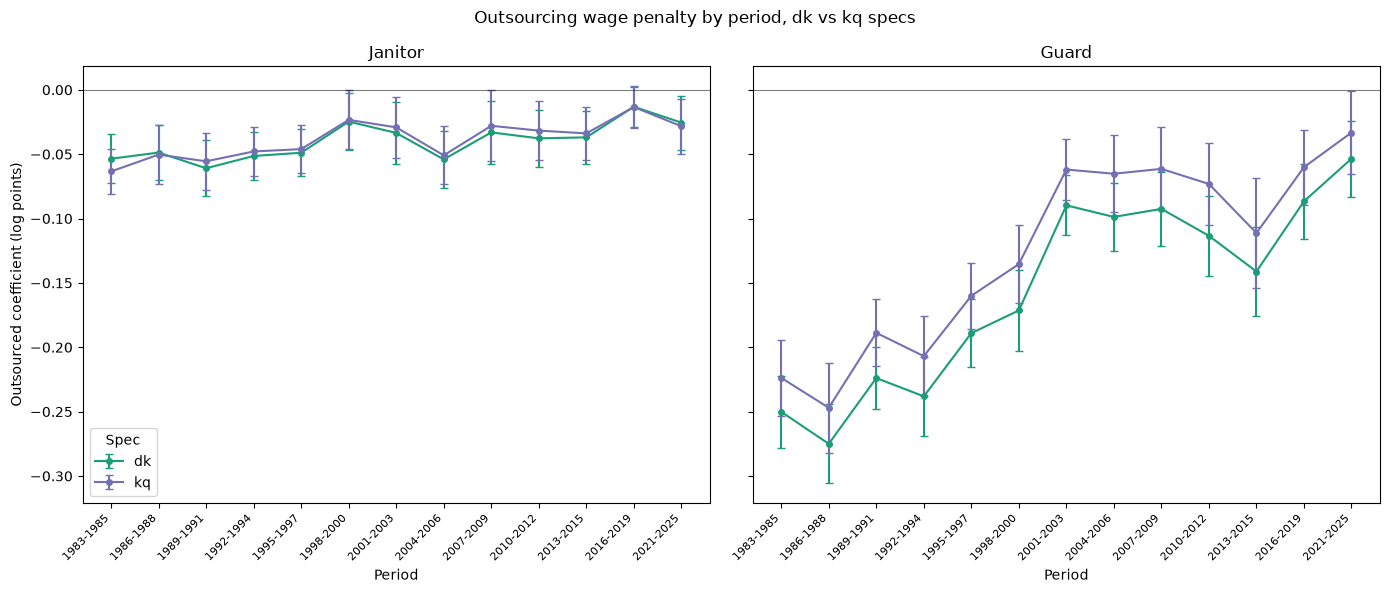

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
colors = {"dk": "#1b9e77", "kq": "#7570b3"}
for ax, occ in zip(axes, ["janitor", "guard"]):
    for spec in ["dk", "kq"]:
        sub = by_period_table[(by_period_table["occ"] == occ) & (by_period_table["spec"] == spec)].set_index("sample").reindex(period_labels)
        x = np.arange(len(period_labels))
        ax.errorbar(x, sub["estimate"].to_numpy(dtype=float), yerr=1.96 * sub["se"].to_numpy(dtype=float),
                    marker="o", markersize=4, capsize=3, label=spec, color=colors[spec])
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_xticks(np.arange(len(period_labels)))
    ax.set_xticklabels(period_labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(occ.capitalize())
    ax.set_xlabel("Period")
axes[0].set_ylabel("Outsourced coefficient (log points)")
axes[0].legend(title="Spec")
fig.suptitle("Outsourcing wage penalty by period, dk vs kq specs")
fig.tight_layout()
fig.savefig("../outputs/figures/by_period_outsourced.png", dpi=150)
plt.show()

### kq penalty over time, both occupations on one plot

Source: `refs/kq_spec.md` (kq = dk plus gov_employee). Reads the kq by-period
`outsourced` estimates from `outputs/py/estimates.csv` (section 4), so this
cell runs without refitting. Same 13 period bins as section 4.

In [ ]:
period_labels = ["1983-1985","1986-1988","1989-1991","1992-1994","1995-1997","1998-2000",
                 "2001-2003","2004-2006","2007-2009","2010-2012","2013-2015","2016-2019","2021-2025"]

saved = pd.read_csv("../outputs/py/estimates.csv")
kq_pen = saved[(saved["spec"] == "kq") & (saved["model"] == "base") & (saved["term"] == "outsourced")
               & (saved["sample"].isin(period_labels))]

fig, ax = plt.subplots(figsize=(11, 6))
colors = {"janitor": "#1b9e77", "guard": "#d95f02"}
x = np.arange(len(period_labels))
for occ in ["janitor", "guard"]:
    sub = kq_pen[kq_pen["occ"] == occ].set_index("sample").reindex(period_labels)
    ax.errorbar(x, sub["estimate"].to_numpy(dtype=float), yerr=1.96 * sub["se"].to_numpy(dtype=float),
                marker="o", markersize=4, capsize=3, linewidth=1.5, color=colors[occ],
                label=occ.capitalize())
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(period_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Period")
ax.set_ylabel("Outsourced coefficient (log points)")
ax.set_title("Outsourcing wage penalty over time, kq spec (95% CI)")
ax.legend(title="Occupation")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../outputs/figures/kq_penalty_by_period.png", dpi=150)
plt.show()

## 5. Union mediation (kq), pooled and by period

Source: `refs/kq_spec.md` "## Union mediation (not in D&K)". For each
occupation and sample: `mediated_penalty = (u_inhouse - u_outsourced) *
beta_union` (from the kq base model already fit above) and `pct_explained =
mediated_penalty / |beta_outsourced|` (from a `nounion` model on the *same*
sample). Union rates are EARNWT-weighted means within that sample.
Descriptive decomposition, not causal. Reuses the kq base fits from
sections 3–4 rather than refitting; only the `nounion` model is new.

In [ ]:
mediation_rows = []
all_samples = list(periods_pooled.keys()) + period_labels
for occ in ["janitor", "guard"]:
    for sample in all_samples:
        key_base = (occ, "kq", "base", sample)
        if key_base not in fit_cache:
            continue
        kq_fit, kq_sample = fit_cache[key_base]
        kq_coefs = kq_fit.tidy().reset_index().set_index("Coefficient")
        if "union" not in kq_coefs.index:
            continue
        beta_union = kq_coefs.loc["union", "Estimate"]

        out_mask = kq_sample["outsourced"] == 1
        in_mask = kq_sample["outsourced"] == 0
        u_out = np.average(kq_sample.loc[out_mask, "union"], weights=kq_sample.loc[out_mask, "EARNWT"])
        u_in = np.average(kq_sample.loc[in_mask, "union"], weights=kq_sample.loc[in_mask, "EARNWT"])

        nounion_fit, _ = fit_and_record(kq_nounion_formula, kq_sample, kq_nounion_terms, "python", "kq", "nounion", occ, sample)
        beta_out_nounion = nounion_fit.tidy().reset_index().set_index("Coefficient").loc["outsourced", "Estimate"]

        mediated = (u_in - u_out) * beta_union
        pct_explained = mediated / abs(beta_out_nounion)
        mediation_rows.append(dict(occ=occ, sample=sample, u_inhouse=u_in, u_outsourced=u_out,
                                    beta_union=beta_union, beta_outsourced_nounion=beta_out_nounion,
                                    mediated_penalty=mediated, pct_explained=pct_explained, n_obs=kq_fit._N))

mediation = pd.DataFrame(mediation_rows)
print(mediation.round(4).to_string(index=False))
mediation.to_csv("../outputs/py/mediation.csv", index=False)

/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['cc_unknown'].
            
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['cc_unknown'].
            
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['cc_unknown'].
            
  warnings.warn(
/Users/kq/opt/anaconda3/envs/outsourcing/lib/python3.12/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped d

    occ    sample  u_inhouse  u_outsourced  beta_union  beta_outsourced_nounion  mediated_penalty  pct_explained  n_obs
janitor 1983-2000     0.2358        0.1467      0.2462                  -0.0460            0.0220         0.4773  57297
janitor 2001-2025     0.1871        0.0944      0.1292                  -0.0296            0.0120         0.4040  60356
janitor 1983-1985     0.2715        0.1887      0.2536                  -0.0582            0.0210         0.3608   9947
janitor 1986-1988     0.2531        0.1719      0.2671                  -0.0485            0.0217         0.4472  10643
janitor 1989-1991     0.2409        0.1528      0.2752                  -0.0554            0.0242         0.4373  10517
janitor 1992-1994     0.2290        0.1377      0.2357                  -0.0464            0.0215         0.4633   9457
janitor 1995-1997     0.2166        0.1289      0.2224                  -0.0444            0.0195         0.4390   8494
janitor 1998-2000     0.2075        0.12

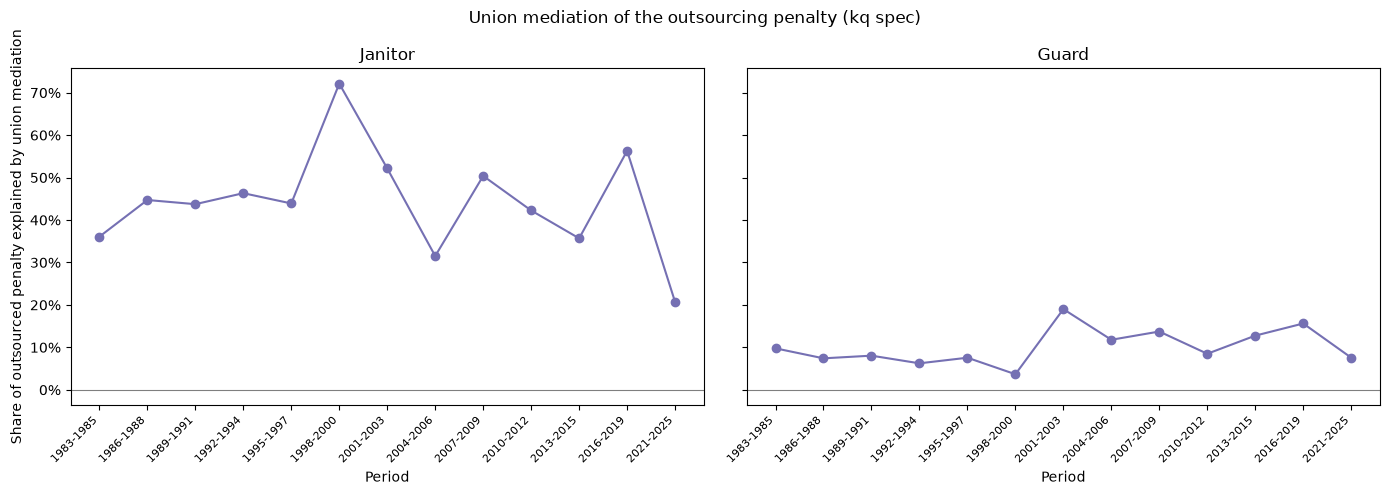

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, occ in zip(axes, ["janitor", "guard"]):
    sub = mediation[(mediation["occ"] == occ) & (mediation["sample"].isin(period_labels))].set_index("sample").reindex(period_labels)
    x = np.arange(len(period_labels))
    ax.plot(x, sub["pct_explained"].to_numpy(dtype=float), marker="o", color="#7570b3")
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_xticks(np.arange(len(period_labels)))
    ax.set_xticklabels(period_labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(occ.capitalize())
    ax.set_xlabel("Period")
axes[0].set_ylabel("Share of outsourced penalty explained by union mediation")
axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1))
fig.suptitle("Union mediation of the outsourcing penalty (kq spec)")
fig.tight_layout()
fig.savefig("../outputs/figures/union_mediation.png", dpi=150)
plt.show()

## 6. Summary statistics (kq spec), 2001–2025

Source: `refs/kq_spec.md` "## Summary statistics (2001-2025)". Weighted
means by outsourcing status within 5-year bins (2001-05, 06-10, 11-15,
2016-19, 2021-25; irregular widths as specified). Uses `real_wage_trimmed`
(per `refs/cleaning.md`: trimmed real wage, "used in summary statistics"),
not plain `real_wage`. Each variable's mean uses its own non-missing rows
within the occ/period/outsourced group (no cross-variable listwise
deletion -- this is a descriptive table, not a regression sample).

In [ ]:
def weighted_mean_se(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = ~np.isnan(x)
    x, w = x[mask], w[mask]
    if len(x) == 0:
        return np.nan, np.nan, 0
    wbar = np.sum(w * x) / np.sum(w)
    wvar = np.sum(w * (x - wbar) ** 2) / np.sum(w)
    n_eff = (np.sum(w) ** 2) / np.sum(w ** 2)
    return wbar, np.sqrt(wvar / n_eff), len(x)

summary_bins = [(2001,2005),(2006,2010),(2011,2015),(2016,2019),(2021,2025)]
summary_vars = ["real_wage_trimmed", "union", "parttime", "age", "female", "black", "hispanic", "gov_employee"]
educ_levels = ["college", "no_school", "primary", "hs_attend", "hs_complete", "some_college"]

summary_rows = []
for occ in ["janitor", "guard"]:
    for (y0, y1) in summary_bins:
        label = f"{y0}-{y1}"
        base = dk_clean[(dk_clean["occupation"] == occ) & dk_clean["YEAR"].between(y0, y1)]
        for status, g in base.groupby("outsourced"):
            status_label = "outsourced" if status == 1 else "in_house"
            for var in summary_vars:
                m, se, n = weighted_mean_se(g[var], g["EARNWT"])
                summary_rows.append(dict(occ=occ, sample=label, outsourced=status_label, variable=var, mean=m, se=se, n=n))
            for lvl in educ_levels:
                ind = (g["educ_cat"] == lvl).astype(float)
                m, se, n = weighted_mean_se(ind, g["EARNWT"])
                summary_rows.append(dict(occ=occ, sample=label, outsourced=status_label, variable=f"educ_cat_{lvl}", mean=m, se=se, n=n))

summary_long = pd.DataFrame(summary_rows)
wide = summary_long.pivot_table(index=["occ", "sample", "variable"], columns="outsourced", values=["mean", "se"])
wide.columns = [f"{a}_{b}" for a, b in wide.columns]
wide = wide.reset_index()
wide["diff"] = wide["mean_outsourced"] - wide["mean_in_house"]
wide["se_diff"] = np.sqrt(wide["se_in_house"] ** 2 + wide["se_outsourced"] ** 2)
print(wide.round(3).to_string(index=False))
wide.to_csv("../outputs/py/summary_stats_2001_2025.csv", index=False)

    occ    sample              variable  mean_in_house  mean_outsourced  se_in_house  se_outsourced   diff  se_diff
  guard 2001-2005                   age         41.406           41.388        0.319          0.341 -0.018    0.467
  guard 2001-2005                 black          0.238            0.323        0.009          0.011  0.085    0.014
  guard 2001-2005      educ_cat_college          0.163            0.104        0.008          0.007 -0.058    0.010
  guard 2001-2005    educ_cat_hs_attend          0.074            0.098        0.006          0.007  0.024    0.009
  guard 2001-2005  educ_cat_hs_complete          0.384            0.449        0.010          0.011  0.065    0.015
  guard 2001-2005    educ_cat_no_school          0.000            0.000        0.000          0.000  0.000    0.000
  guard 2001-2005      educ_cat_primary          0.019            0.027        0.003          0.004  0.008    0.005
  guard 2001-2005 educ_cat_some_college          0.360            0.322 

## Save master estimates

All regression coefficients from sections 2–5, long format, per `CLAUDE.md`.

In [ ]:
estimates_all = pd.DataFrame(master)
print("master estimates shape:", estimates_all.shape)
estimates_all.to_csv("../outputs/py/estimates.csv", index=False)
print("saved outputs/py/estimates.csv")

master estimates shape: (1617, 11)
saved outputs/py/estimates.csv
